# CO2 Emissions and Global Temperature: A Data Analysis Project

## Overview
This project explores the relationship between global CO2 emissions and rising global temperatures using real-world datasets (Our World in Data for CO2 emissions, NASA GISTEMP for temperature records). The analysis combines data cleaning, exploratory analysis, and linear regression modeling with NumPy and Pandas to quantify how strongly CO2 emissions are associated with global warming.

## Objectives
- Analyze long-term trends (1880–2023) in global CO2 emissions and surface temperature anomalies
- Compare total and per-capita emissions across the top emitting countries (e.g., China, USA)
- Calculate annual CO2 growth rates and identify historical turning points (e.g., WWI, WWII)
- Fit a linear regression model to test the statistical relationship between CO2 and temperature

## Data Sources
- CO2 emissions data: Our World in Data
- Global temperature data: NASA GISTEMP

## Key Findings
A summary of results and the regression analysis is presented in the accompanying slide deck (`CO2-GitHub-ppt.pptx`).



# Introduction

Global warming is a major public concern. Understanding how the Earth's surface temperature is changing, its trends, and its prediction is crucial, which is important for many fields (agriculture, energy efficiency, greenhouse gas emission control, energy industry restructuring, etc.).

The main goal of this project is to gain insights into how CO2 and global temperature change over time, taking into account all potential factors. 

## Data sources

For this analysis, I use two main datasets:

1. **Our World in Data – CO2 and Greenhouse Gas Emissions**  
   - Source: https://ourworldindata.org/co2-and-greenhouse-gas-emissions  
   - File: owid-co2-data.csv 
   - Main columns used:  
     "country", "year", "co2", "co2_per_capita", "co2_growth_prct", "population", "iso_code"
     This dataset contains the CO2 emissions of countries (million tonnes) per year, and in the "Country" column we have the numbers "World", "Asia",
     "Europe" and so on.
     The "co2_per_capita" column is a number that shows annual CO₂ emissions per capita (million tonnes) and the "co2_growth_prct" column shows annual
     CO2 percentage growth in total emissions of carbon dioxide. 
3. **NASA GISS Surface Temperature Analysis (GISTEMP v4)**  
   - Source: https://data.giss.nasa.gov/gistemp/  
   - File: GLB.Ts+dSST.csv 
   - Main columns used:  
     "Year", "J-D"  
     Column "J-D" represents yearly global temperature anomalies (°C) with float numbers.

## Programs


In [519]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


In [520]:
df_co2 = pd.read_csv("owid-co2-data.csv")
df_co2

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.000,0.000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50186,Zimbabwe,2019,ZWE,15271377.0,2.514642e+10,0.473,0.031,10.263,-0.942,-8.411,...,NaN,0.106,0.001,0.001,0.002,0.0,34.348,17.531,-0.027,-0.261
50187,Zimbabwe,2020,ZWE,15526888.0,2.317871e+10,0.496,0.032,8.495,-1.768,-17.231,...,NaN,0.105,0.001,0.001,0.002,0.0,31.323,15.775,0.612,7.209
50188,Zimbabwe,2021,ZWE,15797220.0,2.514009e+10,0.531,0.034,10.204,1.709,20.120,...,NaN,0.104,0.001,0.001,0.002,0.0,33.549,17.599,0.539,5.280
50189,Zimbabwe,2022,ZWE,16069061.0,2.590159e+10,0.531,0.033,10.425,0.221,2.169,...,NaN,0.103,0.001,0.001,0.002,0.0,33.772,17.910,0.315,3.018


As we can see from the "CO2" dataframe, there are columns country, year, population, gdp, cement_co2, cement_co2_per_capita,...
In this project, I will focus on changes in total CO2 emissions in countries based on different years, CO2 emissions per person and CO2 growth compared to previous years.

In [195]:
df_temp = pd.read_csv("GLB.Ts+dSST.csv")
df_temp

,,,,,,,,,,,,,,,,,,Land-Ocean: Global Means
Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
1880,-.19,-.25,-.09,-.16,-.10,-.21,-.18,-.10,-.15,-.24,-.22,-.18,-.17,***,***,-.12,-.16,-.20
1881,-.20,-.14,.03,.05,.06,-.19,.00,-.03,-.15,-.22,-.19,-.07,-.09,-.10,-.17,.05,-.07,-.18
1882,.16,.14,.04,-.17,-.14,-.23,-.16,-.07,-.14,-.24,-.17,-.36,-.11,-.09,.08,-.09,-.15,-.18
1883,-.29,-.36,-.12,-.18,-.17,-.07,-.06,-.13,-.21,-.11,-.23,-.11,-.17,-.19,-.34,-.15,-.09,-.18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021,.81,.64,.89,.76,.79,.84,.92,.81,.92,.98,.92,.87,.85,.84,.75,.81,.86,.94
2022,.91,.89,1.04,.83,.84,.92,.94,.95,.89,.96,.73,.80,.89,.90,.89,.91,.94,.86
2023,.87,.97,1.23,.99,.94,1.08,1.19,1.19,1.48,1.34,1.41,1.37,1.17,1.12,.88,1.05,1.15,1.41
2024,1.25,1.44,1.39,1.31,1.14,1.20,1.20,1.30,1.23,1.34,1.29,1.27,1.28,1.29,1.35,1.28,1.23,1.28


As we can see from the "Surface Temperature" dataframe, there are columns Year, each month temperature and the J-D which is showing the yearly temperature,...
In this project, I will focus on tempreature changes based on different years and the yearly temperature change.

Since we want to analyze the data and extract patterns, I want to merge these two data frames together based on the years they share. So, I just read from cvs columns and rows from the year 1880 until 2023.


In [390]:
co2 = pd.read_csv("owid-co2-data.csv")[["country","year","population","co2","co2_growth_prct","co2_per_capita","iso_code"]]
co2=co2[(co2["year"]>=1880)& (co2["year"]<=2023)]
co2

,country,year,population,co2,co2_growth_prct,co2_per_capita,iso_code
130,Afghanistan,1880,4288021.0,NaN,NaN,NaN,AFG
131,Afghanistan,1881,4307129.0,NaN,NaN,NaN,AFG
132,Afghanistan,1882,4326316.0,NaN,NaN,NaN,AFG
133,Afghanistan,1883,4345580.0,NaN,NaN,NaN,AFG
134,Afghanistan,1884,4364922.0,NaN,NaN,NaN,AFG
...,...,...,...,...,...,...,...
50186,Zimbabwe,2019,15271377.0,10.263,-8.411,0.672,ZWE
50187,Zimbabwe,2020,15526888.0,8.495,-17.231,0.547,ZWE
50188,Zimbabwe,2021,15797220.0,10.204,20.120,0.646,ZWE
50189,Zimbabwe,2022,16069061.0,10.425,2.169,0.649,ZWE


In [197]:
temp = pd.read_csv("GLB.Ts+dSST.csv", skiprows=1)[["Year","J-D"]]
temp=temp[(temp["Year"]>=1880)& (temp["Year"]<=2023)]
temp

,Year,J-D
0,1880,-.17
1,1881,-.09
2,1882,-.11
3,1883,-.17
4,1884,-.28
...,...,...
139,2019,.98
140,2020,1.01
141,2021,.85
142,2022,.89


At this step, I want to have the same name for the column year to be able to merge 2 data frames and also I want to check that the type of this column is in the same format(integer).


In [391]:
co2 = co2.rename(columns={'year': 'Year'})

print(co2["Year"].dtype)

co2

int64


,country,Year,population,co2,co2_growth_prct,co2_per_capita,iso_code
130,Afghanistan,1880,4288021.0,NaN,NaN,NaN,AFG
131,Afghanistan,1881,4307129.0,NaN,NaN,NaN,AFG
132,Afghanistan,1882,4326316.0,NaN,NaN,NaN,AFG
133,Afghanistan,1883,4345580.0,NaN,NaN,NaN,AFG
134,Afghanistan,1884,4364922.0,NaN,NaN,NaN,AFG
...,...,...,...,...,...,...,...
50186,Zimbabwe,2019,15271377.0,10.263,-8.411,0.672,ZWE
50187,Zimbabwe,2020,15526888.0,8.495,-17.231,0.547,ZWE
50188,Zimbabwe,2021,15797220.0,10.204,20.120,0.646,ZWE
50189,Zimbabwe,2022,16069061.0,10.425,2.169,0.649,ZWE


In [392]:
temp = temp.rename(columns={'J-D': 'yearly_temp_anomaly'})

print(temp["Year"].dtype)

temp

int32


,Year,yearly_temp_anomaly
0,1880,-0.17
1,1881,-0.09
2,1882,-0.11
3,1883,-0.17
4,1884,-0.28
...,...,...
139,2019,0.98
140,2020,1.01
141,2021,0.85
142,2022,0.89


In [393]:
co2[["country","Year","population","co2","co2_growth_prct","co2_per_capita","iso_code"]].isna().sum()

country                0
Year                   0
population          4714
co2                11401
co2_growth_prct    13349
co2_per_capita     13296
iso_code            5012
dtype: int64

In [394]:
temp[["Year","yearly_temp_anomaly"]].isna().sum()

Year                   0
yearly_temp_anomaly    0
dtype: int64

## Questions

- How CO2 emissions have changed over time
- How global average temperatures have changed
- Whether there is a clear correlation between CO2 levels and temperature anomalies
- Is there a relationship between population growth in the top three CO2 emitting countries and emissions rate?
- Is there a linear relationship between increasing global CO2 emissions and increasing temperature anomaly?
- Analysis of the annual growth of the percentage of CO2 in total carbon dioxide emissions

 **The earth surface temperature change trend** 


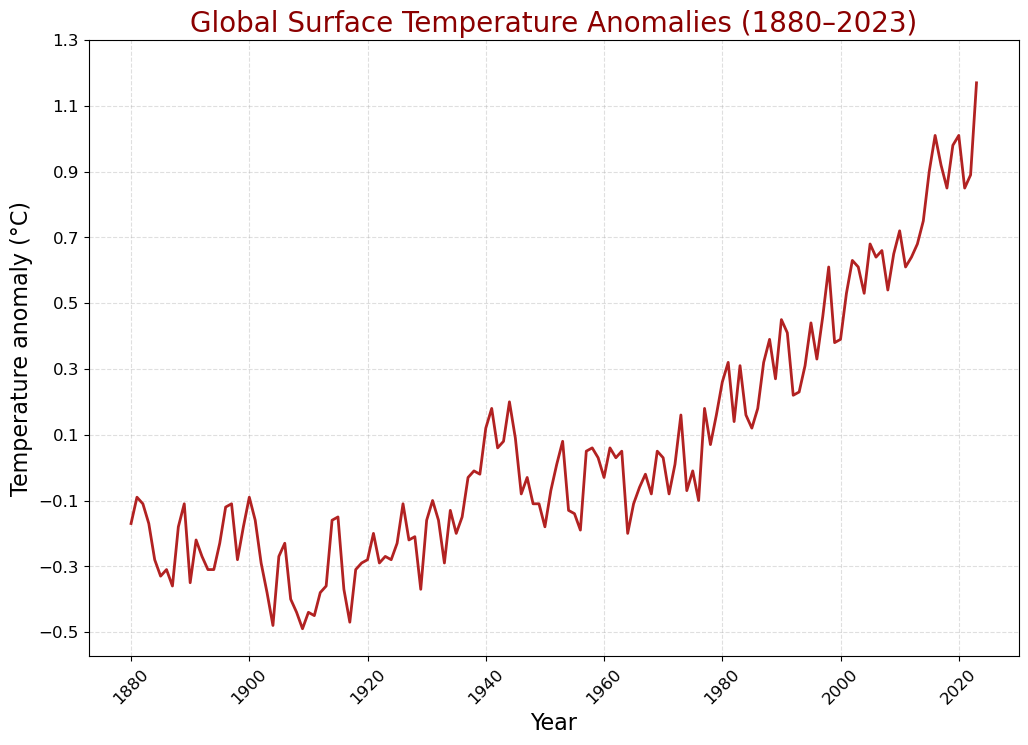

In [395]:
fig, ax = plt.subplots(figsize=(12,8))
ax.plot(temp['Year'], temp['yearly_temp_anomaly'],linewidth=2, color='firebrick')
ax.set_xlabel('Year', fontsize=16)
ax.set_ylabel('Temperature anomaly (°C)', fontsize=16)
ax.set_title('Global Surface Temperature Anomalies (1880–2023)', fontsize=20, color='darkred')
ax.set_xticks(np.arange(1880, 2031, 20))
ax.set_yticks(np.arange(-0.5, 1.5, 0.2))
ax.tick_params(axis='x', labelsize=12, rotation=45)
ax.tick_params(axis='y', labelsize=12)
ax.grid(True, linestyle='--', alpha=0.4)
plt.show()

#As we can see from the plot, there is a clear trend showing global average surface temperature is raising from 18th century to now.
#We can also see that before 1950s, temperature increase was slow and after that rapid growth started.

**Carbon dioxide concentration changes over time**



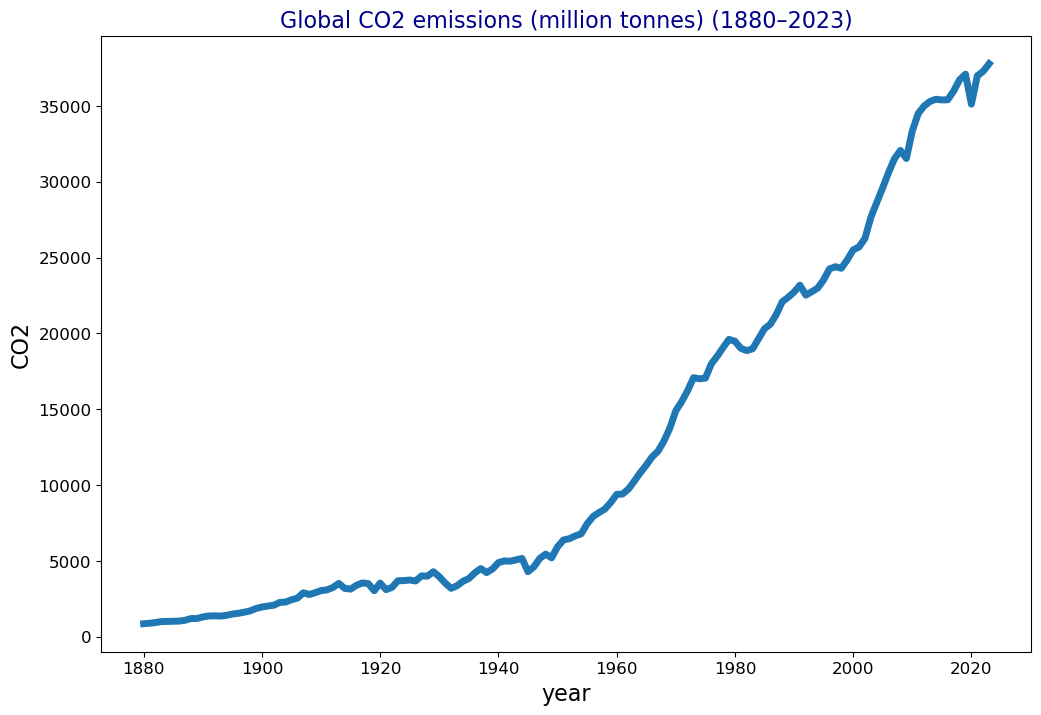

In [396]:
plt.figure(figsize=(12,8))
plt.plot(co2[co2['country'] == 'World']["Year"],co2[co2['country'] == 'World']["co2"],linewidth=5)
plt.xticks(np.arange(1880,2023,20),fontsize=12);
plt.xlabel('year',fontsize=16)
plt.ylabel('CO2', fontsize=16)
plt.title('Global CO2 emissions (million tonnes) (1880–2023)', fontsize=16, color='darkblue')
plt.yticks(fontsize=12)
plt.show()
#In this plot, the co2 in air also increases from 18th century to now, especially after 1950s, we can see significant raise in ascending rate.
#This rapid growth after 1950s is the same as what happend for the global surface temperature growth on 1950s.
#Here for the CO2 we see CO2 values keeps increasing continuously while the global surface temperature has fluctutaions specially before 1950s. 

**Carbon dioxide and Temperature changes over time in one figure**



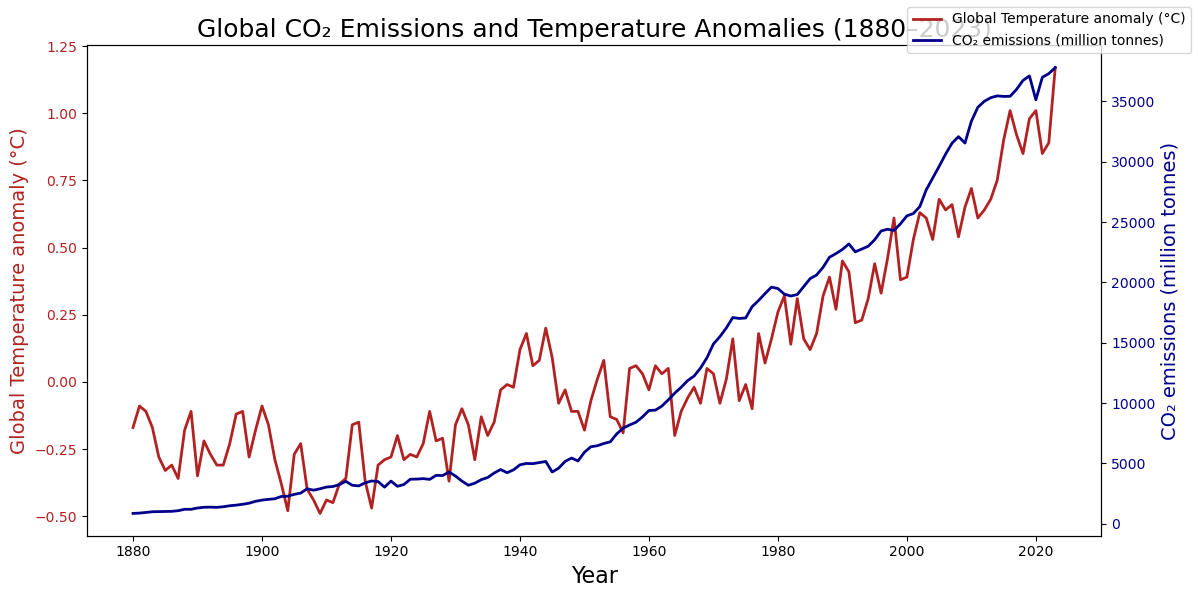

In [397]:
world_co2 = co2[co2['country'] == 'World']

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(temp['Year'], temp['yearly_temp_anomaly'], color='firebrick', linewidth=2, label='Global Temperature anomaly (°C)')
ax1.set_xlabel('Year', fontsize=16)
ax1.set_ylabel('Global Temperature anomaly (°C)', color='firebrick', fontsize=14)
ax1.tick_params(axis='y', labelcolor='firebrick')

ax2 = ax1.twinx()
ax2.plot(co2[co2['country'] == 'World']['Year'], co2[co2['country'] == 'World']['co2'], color='darkblue', linewidth=2, label='CO₂ emissions (million tonnes)')
ax2.set_ylabel('CO₂ emissions (million tonnes)', color='darkblue', fontsize=14)
ax2.tick_params(axis='y', labelcolor='darkblue')

plt.title('Global CO₂ Emissions and Temperature Anomalies (1880–2023)', fontsize=18)
fig.tight_layout()
fig.legend()
plt.show()

#In this figure we can see the results in the previous cells better.

In [398]:
merged_df = pd.merge(co2[co2['country'] == 'World'], temp, on='Year', how='inner')
merged_df

,country,Year,population,co2,co2_growth_prct,co2_per_capita,iso_code,yearly_temp_anomaly
0,World,1880,1.427719e+09,858.056,12.933,0.601,NaN,-0.17
1,World,1881,NaN,887.965,3.486,NaN,NaN,-0.09
2,World,1882,NaN,937.888,5.622,NaN,NaN,-0.11
3,World,1883,NaN,997.515,6.358,NaN,NaN,-0.17
4,World,1884,NaN,1009.430,1.195,NaN,NaN,-0.28
...,...,...,...,...,...,...,...,...
139,World,2019,7.811294e+09,37104.273,1.018,4.750,NaN,0.98
140,World,2020,7.887001e+09,35126.527,-5.330,4.454,NaN,1.01
141,World,2021,7.954448e+09,36991.734,5.310,4.650,NaN,0.85
142,World,2022,8.021407e+09,37293.836,0.817,4.649,NaN,0.89


**Carbon dioxide correlation with temperature changes over time**



In [483]:
corr = merged_df['co2'].corr(merged_df['yearly_temp_anomaly'])
print(f"Correlation between CO₂ emissions and temperature anomalies: {corr:.3f}")
#This correlation shows positive relationship between global CO₂ emissions and temperature anomalies.

Correlation between CO₂ emissions and temperature anomalies: 0.933


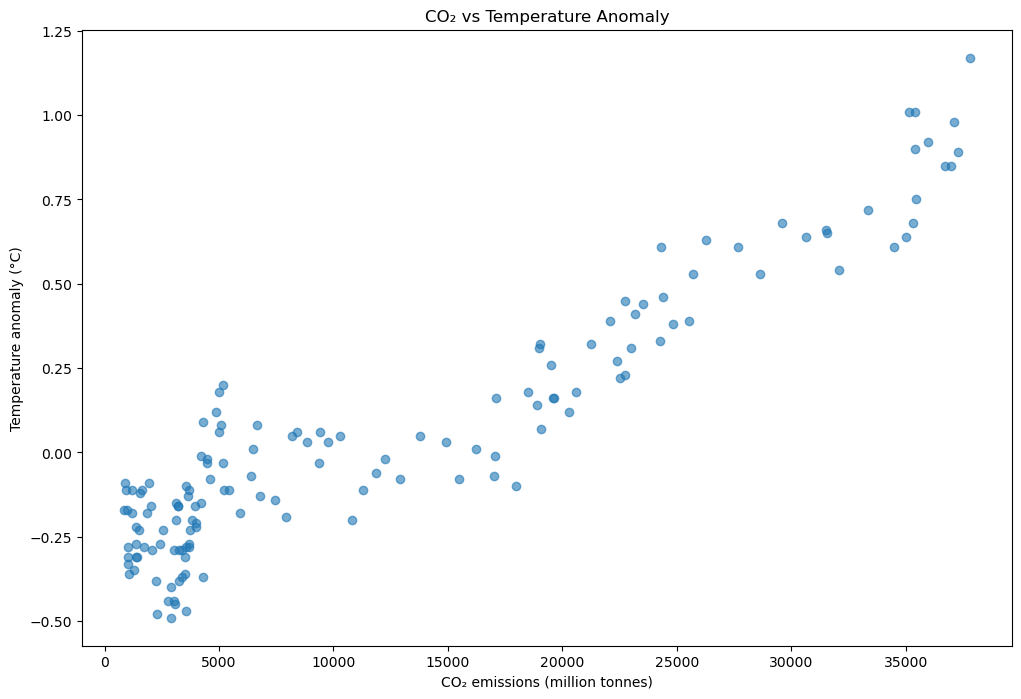

In [399]:
plt.figure(figsize=(12,8))
plt.scatter(merged_df['co2'], merged_df['yearly_temp_anomaly'], alpha=0.6)
plt.title('CO₂ vs Temperature Anomaly')
plt.xlabel('CO₂ emissions (million tonnes)')
plt.ylabel('Temperature anomaly (°C)')
plt.show()
#The scatter plot shows a positive relationship between global CO₂ emissions and temperature anomalies from 1880 to 2023.
#As CO₂ emissions increase, the Earth's surface temperature also increases.
#This shows that CO2 emissions contribute to global warming.

**Top 3 countries and their CO2 changes over time**

In [410]:
co2_countries= co2[co2['iso_code'].notna()].copy()
top_countries = co2_countries.groupby('country')['co2'].sum().sort_values(ascending=False).head(3)
print(top_countries)
lst_top_countries=top_countries.index
print(lst_top_countries)

country
United States    429383.917
China            272531.538
Russia           121209.986
Name: co2, dtype: float64
Index(['United States', 'China', 'Russia'], dtype='object', name='country')


In [434]:
top3_countries=co2_countries[co2_countries["country"].isin(lst_top_countries)]
top3_countries

,country,Year,population,co2,co2_growth_prct,co2_per_capita,iso_code
9742,China,1880,365789113.0,NaN,NaN,NaN,CHN
9743,China,1881,366821065.0,NaN,NaN,NaN,CHN
9744,China,1882,367889208.0,NaN,NaN,NaN,CHN
9745,China,1883,368993727.0,NaN,NaN,NaN,CHN
9746,China,1884,370101546.0,NaN,NaN,NaN,CHN
...,...,...,...,...,...,...,...
47795,United States,2019,337790068.0,5262.145,-2.151,15.578,USA
47796,United States,2020,339436157.0,4714.628,-10.405,13.890,USA
47797,United States,2021,340161441.0,5032.213,6.736,14.794,USA
47798,United States,2022,341534041.0,5078.871,0.927,14.871,USA


**Top three countries in carbon dioxide emissions and their population changes over time**

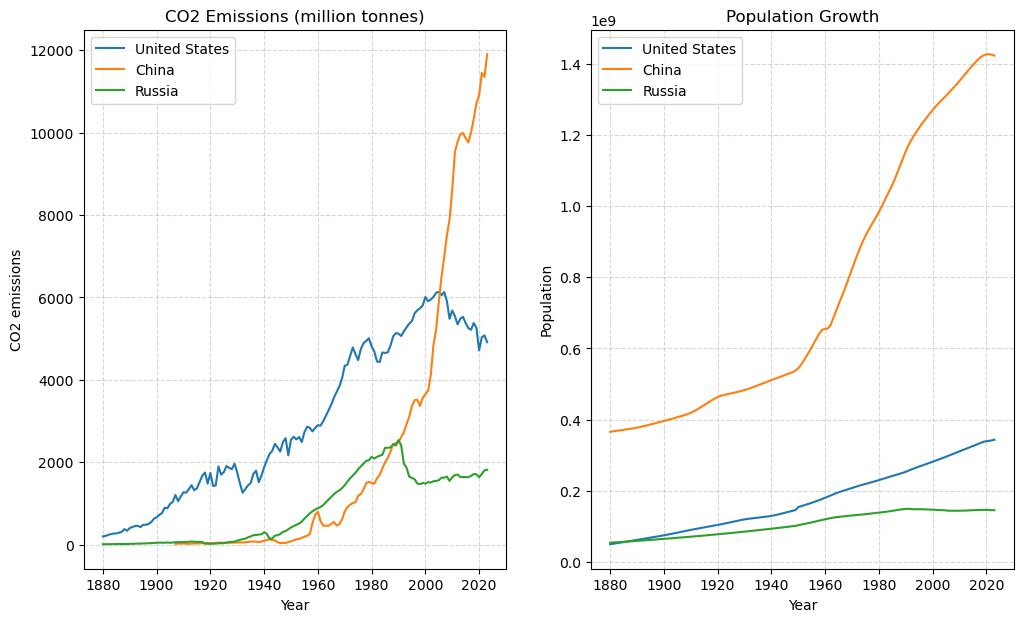

In [482]:
fig, axes = plt.subplots(1, 2, figsize=(12,7))

for country in lst_top_countries:
    data = top3_countries[top3_countries['country'] == country]
    axes[0].plot(data['Year'], data['co2'], label=country)
axes[0].set_title('CO2 Emissions (million tonnes)')
axes[0].set_ylabel('CO2 emissions')
axes[0].legend()

for country in lst_top_countries:
    data = top3_countries[top3_countries['country'] == country]
    axes[1].plot(data['Year'], data['population'], label=country)
axes[1].set_title('Population Growth')
axes[1].set_ylabel('Population')
axes[1].legend()

for ax in axes:
    ax.set_xlabel('Year')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

#As the plots show that:
#Population of United States and Russia growth countinusely from 1880 to 2023 and their CO2 emissions emmited increased steadily until 2000 for
#United States and until 1990 for Russia. After these years the amount of CO2 decreased significantly however the population in both countries 
#had increased. We can obtain that this is becuase of cleaner energy policies, improved efficiency, and a shift to natural gas.
#But for China the CO2 figure shows a dramatic rise in CO₂ emissions starting around the early 2000s and also its population increased significantely
#Overall it seems that by dramatic growth in population we have also growth in CO2 in China, but not in Russia and United States.

**Top three countries in carbon dioxide emissions and changes in CO2 emissions per capita over time**

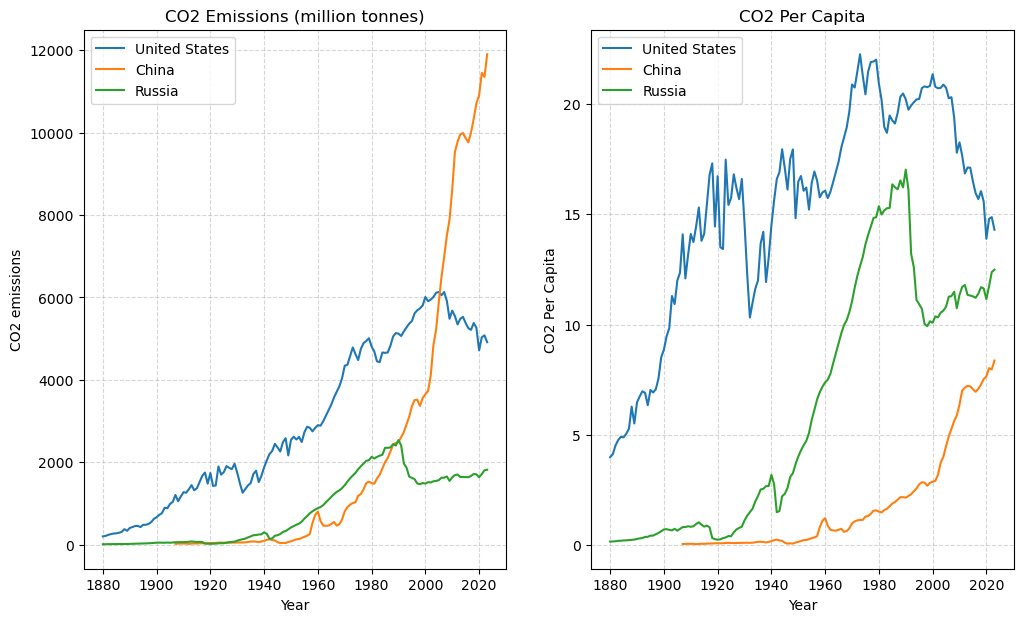

In [466]:
fig, axes = plt.subplots(1, 2, figsize=(12,7))

for country in lst_top_countries:
    data = top3_countries[top3_countries['country'] == country]
    axes[0].plot(data['Year'], data['co2'], label=country)
axes[0].set_title('CO2 Emissions (million tonnes)')
axes[0].set_ylabel('CO2 emissions')
axes[0].legend()

for country in lst_top_countries:
    data = top3_countries[top3_countries['country'] == country]
    axes[1].plot(data['Year'], data['co2_per_capita'], label=country)
axes[1].set_title('CO2 Per Capita')
axes[1].set_ylabel('CO2 Per Capita')
axes[1].legend()

for ax in axes:
    ax.set_xlabel('Year')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

#Based on the previous cell, I just was thinking maybe the correlation between population and CO2 emission is spurious correlation! 
#(we learned this in data science course recently), So I just plotted the figures for showing the CO2 and CO2 per capita to see that are people using more
#CO2 or maybe another factors like industry or other national impacts should be concidered.
#Amazingly we can see that the while China now emits the most CO₂ in total, the United States still has higher per-capita emissions 
#meaning the average American contributes more CO₂ individually than the average Chinese or Russian citizen.
#This is the difference between total national impact and individual carbon footprint!

**Linear regression of CO2 vs Global Temperature**

0.8709546147385947


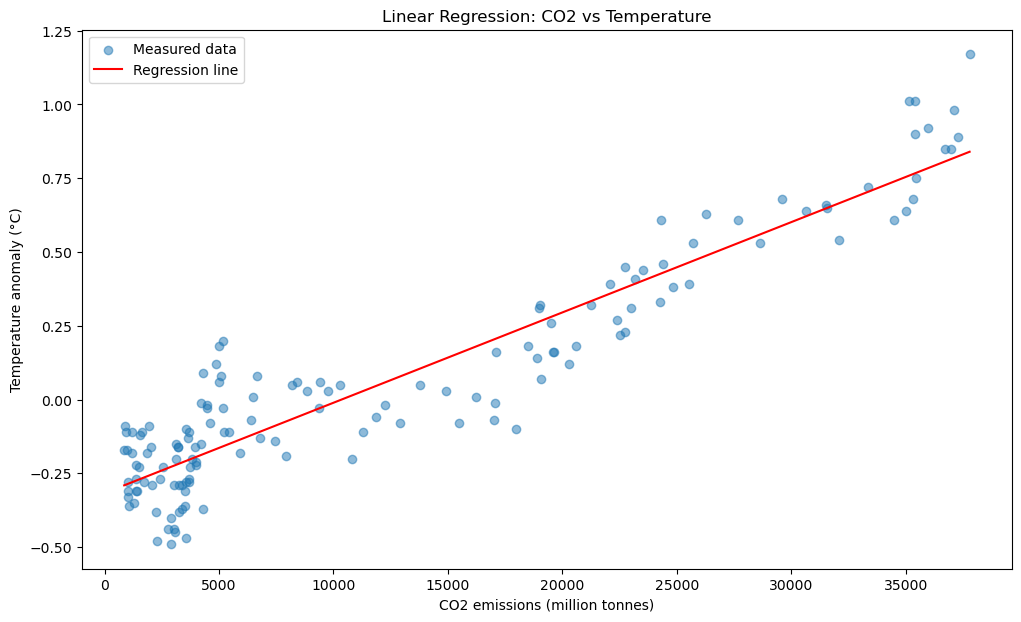

In [525]:
X = merged_df[['co2']].values
y = merged_df['yearly_temp_anomaly'].values

regression_model = LinearRegression()
regression_model.fit(X, y)

train_prediction = regression_model.predict(X)

print(regression_model.score(X,y))

plt.figure(figsize=(12,7))
plt.scatter(X, y, alpha=0.5, label='Measured data')
plt.plot(X, train_prediction, color='red', label='Regression line')
plt.xlabel('CO2 emissions (million tonnes)')
plt.ylabel('Temperature anomaly (°C)')
plt.title('Linear Regression: CO2 vs Temperature')
plt.legend()
plt.show()
#The result shows the linear relationship between global CO2 emissions and temperature growth.
#The red regression line is close to the measured data points, we can obtain that CO2 has real impact on a large part of the warming trend.
#For this part I learned linear regression steps from this link: https://www.kaggle.com/code/hamelg/python-for-data-27-linear-regression

**Annual growth of CO2**

In [522]:
world = co2[co2['country'] == 'World'][['Year', 'co2_growth_prct']].dropna()

avg_growth= world['co2_growth_prct'].mean()
max_growth= world['co2_growth_prct'].max()
min_growth= world['co2_growth_prct'].min()

year_max=world[world['co2_growth_prct']==max_growth]["Year"].iloc[0]
year_min=world[world['co2_growth_prct']==min_growth]['Year'].iloc[0]

print(f"Average annual CO2 growth rate:{avg_growth:.2f}%")
print(f"Highest growth:{max_growth:.2f}% in {year_max}")
print(f"Lowest growth:{min_growth:.2f}% in {year_min}")

#This shows the average annual CO2 growth rate is 2.87 percent which shows CO2 emissions have increased moderately every year on average since 1880.
#Highest growth is 16.61% in 1920 and the lowest growth is -16.91% in 1945.
#I searched these dates and figured out maybe the world wars was influential on these percentages.
#world war 1 was from (July 28, 1914, to November 11, 1918) and in 1920 the highest growth shows industrial recovery and world war 2 was from 
#(September 1, 1939, to September 2, 1945) which the lowest percentage of growth was for 1945, the last year of world war!

Average annual CO2 growth rate:2.87%
Highest growth:16.61% in 1920
Lowest growth:-16.91% in 1945


## Results and analysis

As conclusion this analysis showed that there is a clear relationship between CO2 emissions and global temperatures. From 1880 until 1950, both CO2 emissions and temperatures were increasing slowly. But after 1950 they began to increase much more rapidly. China now has the highest CO2 emissions overall, however the United States still has the highest per capita emissions. This means that population alone is not the cause of global warming, so energy consumption and industry also have big impact. The average annual growth rate of CO2 is about 2.9%, this shows that CO2 emissions have increased steadily almost every year since 1880. The fastest growth was in 1920 with 16.6% , when industries expanded after World War I, and the slowest was in 1945 with -16.9%, at the end of World War II. I also used a linear regression model to further convince myself that global temperature increases are strongly related to CO2 emissions. This model also shows statistically that increases in CO2 play a major role in global warming.